# SSVI surface diagnostics

Fit one SSVI surface to the screened 2025-08-29 SPX quotes. The quote screen, ATM estimates, and calibration are implemented in `src/ssvi.py`. This notebook inspects their results.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.ssvi import fit_ssvi_surface, ssvi_total_variance

PANEL_PATH = Path("../data/processed/spx_iv_panel_2025-08-29.csv")
panel = pd.read_csv(PANEL_PATH, parse_dates=["quote_date", "expiry_date"])
result = fit_ssvi_surface(panel)
observations = result["observations"]

display(pd.Series({key: result[key] for key in ["rho", "eta", "gamma", "rmse"]}))
display(result["theta_by_expiry"])


rho     -0.382447
eta      1.410054
gamma    0.580221
rmse     0.003747
dtype: float64

,quote_date,expiry_date,time_to_expiry,theta_atm
0,2025-08-29,2025-09-02,0.010959,0.000039
1,2025-08-29,2025-09-03,0.013699,0.000069
2,2025-08-29,2025-09-04,0.016438,0.000109
3,2025-08-29,2025-09-05,0.019178,0.000210
4,2025-08-29,2025-09-08,0.027397,0.000259
5,2025-08-29,2025-09-09,0.030137,0.000310
6,2025-08-29,2025-09-10,0.032877,0.000354
7,2025-08-29,2025-09-11,0.035616,0.000429
8,2025-08-29,2025-09-12,0.038356,0.000474
9,2025-08-29,2025-09-15,0.046575,0.000528


## Representative expiries

For each target DTE, select the closest available expiry. Points are observed midpoint total variance; curves use its estimated $\theta_{\mathrm{ATM}}$ and the shared fitted $\rho$, $\eta$, and $\gamma$.

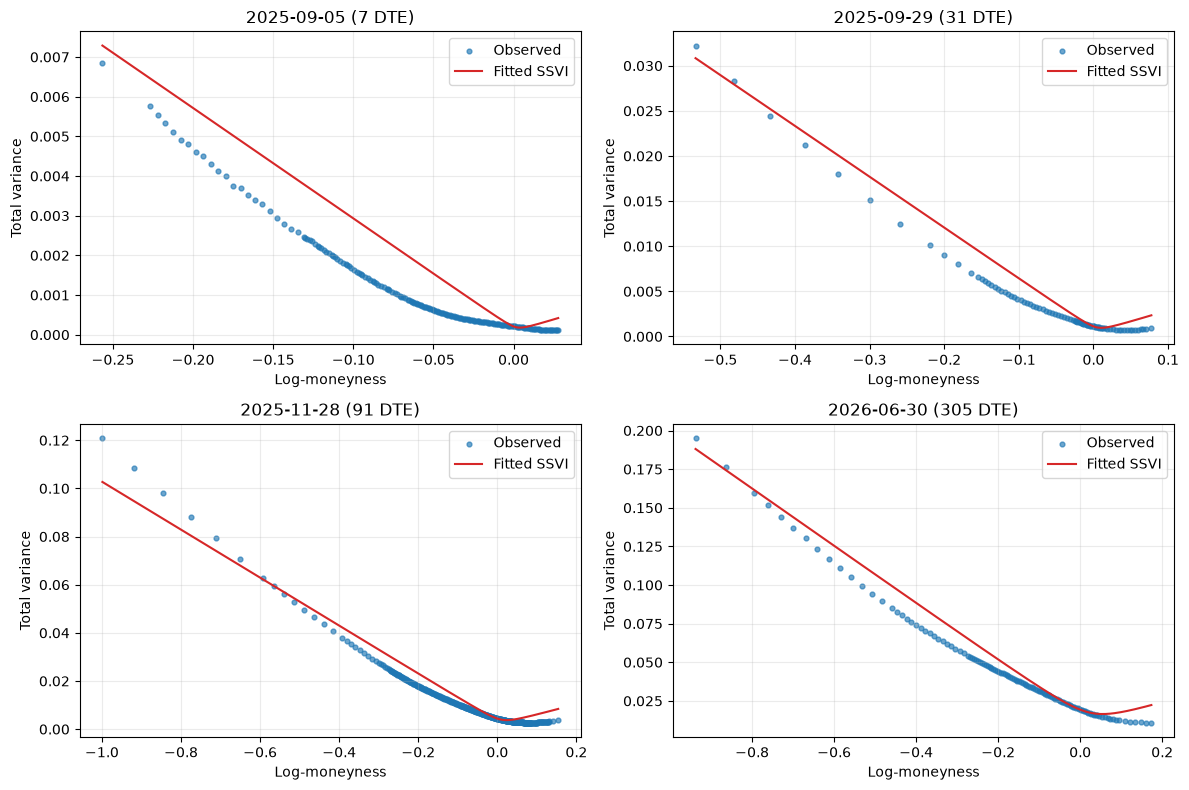

In [6]:
expiry_table = observations[["expiry_date", "days_to_expiry"]].drop_duplicates()
targets = [7, 30, 90, 300]
selected_expiries = []
for target in targets:
    nearest = expiry_table.iloc[(expiry_table["days_to_expiry"] - target).abs().argmin()]
    if nearest["expiry_date"] not in selected_expiries:
        selected_expiries.append(nearest["expiry_date"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, expiry in zip(axes.flat, selected_expiries):
    sample = observations.loc[observations["expiry_date"].eq(expiry)]
    k_grid = np.linspace(sample["log_moneyness"].min(), sample["log_moneyness"].max(), 300)
    theta = sample["theta_atm"].iloc[0]
    ax.scatter(sample["log_moneyness"], sample["market_w"], s=12, alpha=0.65, label="Observed")
    ax.plot(
        k_grid,
        ssvi_total_variance(k_grid, theta, result["rho"], result["eta"], result["gamma"]),
        color="tab:red", label="Fitted SSVI",
    )
    ax.set(title=f"{expiry.date()} ({sample['days_to_expiry'].iloc[0]} DTE)", xlabel="Log-moneyness", ylabel="Total variance")
    ax.legend()
    ax.grid(alpha=0.25)
for ax in axes.flat[len(selected_expiries):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Residuals

The residual is fitted minus observed total variance. Inspect whether errors change systematically with log-moneyness or maturity.

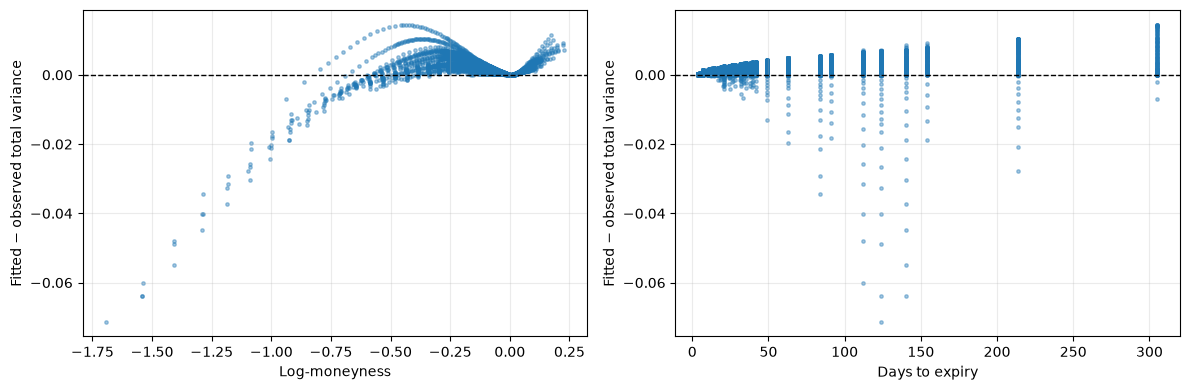

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(observations["log_moneyness"], observations["residual_w"], s=6, alpha=0.4)
axes[1].scatter(observations["days_to_expiry"], observations["residual_w"], s=6, alpha=0.4)
for ax, xlabel in zip(axes, ["Log-moneyness", "Days to expiry"]):
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set(xlabel=xlabel, ylabel="Fitted − observed total variance")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Observed and fitted IV in 3D

The left plot shows the filtered observed IVs. The right plot shows fitted SSVI curves for every expiry, each over the log-moneyness range of that expiry's quotes. The curves are separate expiry slices; no interpolation between expiries is fitted.

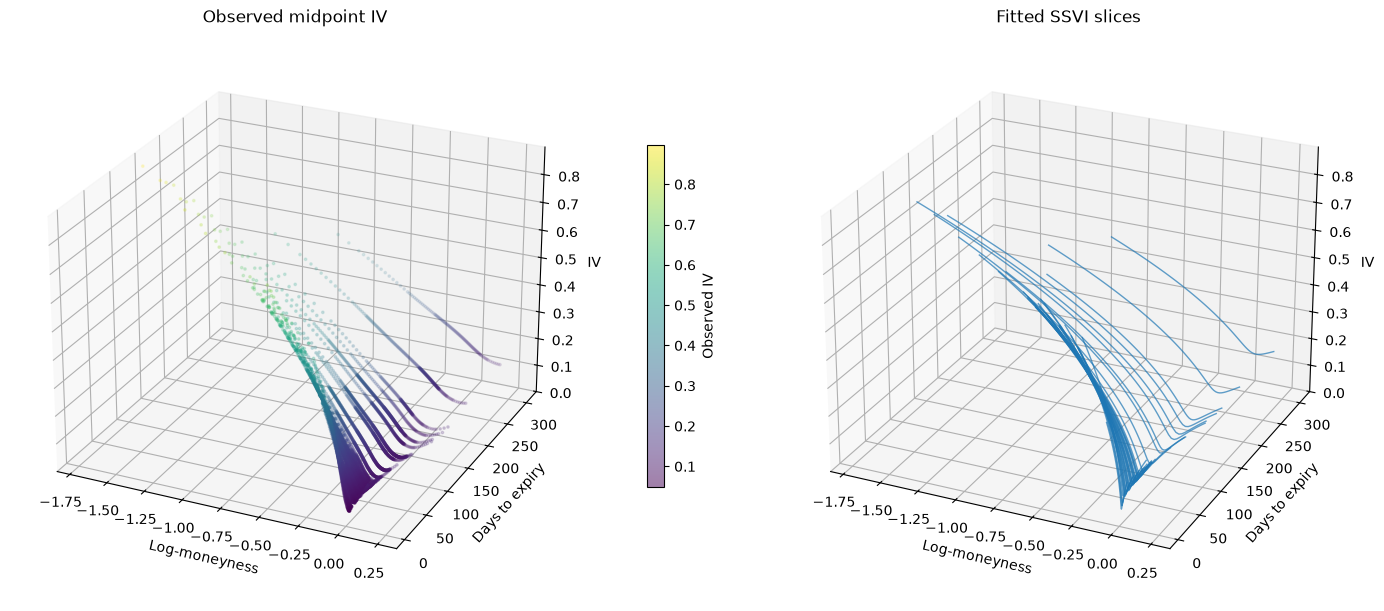

In [8]:
fig = plt.figure(figsize=(15, 6), layout="constrained")
observed_ax = fig.add_subplot(121, projection="3d")
fitted_ax = fig.add_subplot(122, projection="3d")

points = observed_ax.scatter(
    observations["log_moneyness"],
    observations["days_to_expiry"],
    observations["mid_iv"],
    c=observations["mid_iv"], s=3, alpha=0.5, cmap="viridis",
)
fig.colorbar(points, ax=observed_ax, shrink=0.6, pad=0.1, label="Observed IV")

for expiry, sample in observations.groupby("expiry_date"):
    k_grid = np.linspace(sample["log_moneyness"].min(), sample["log_moneyness"].max(), 100)
    theta = sample["theta_atm"].iloc[0]
    tau = sample["time_to_expiry"].iloc[0]
    fitted_iv = np.sqrt(
        ssvi_total_variance(k_grid, theta, result["rho"], result["eta"], result["gamma"]) / tau
    )
    fitted_ax.plot(
        k_grid, np.full_like(k_grid, sample["days_to_expiry"].iloc[0]), fitted_iv,
        color="tab:blue", linewidth=1, alpha=0.7,
    )

for ax, title in [(observed_ax, "Observed midpoint IV"), (fitted_ax, "Fitted SSVI slices")]:
    ax.set(xlabel="Log-moneyness", ylabel="Days to expiry", zlabel="IV", title=title)
    ax.set_zlim(0, observations["mid_iv"].max())
    ax.view_init(elev=25, azim=-65)
plt.show()

## Rendered SSVI surface

Drag the Plotly figure to rotate it and scroll to zoom. The mesh connects fitted expiry slices where adjacent expiries both have filtered quotes. Each row uses that expiry's estimated $\theta_{\mathrm{ATM}}$ and the shared $\rho$, $\eta$, and $\gamma$. The facets between rows are a plotting connection, not an estimated continuous ATM-variance curve.

In [9]:
expiry_ranges = observations.groupby("expiry_date").agg(
    days_to_expiry=("days_to_expiry", "first"),
    time_to_expiry=("time_to_expiry", "first"),
    theta_atm=("theta_atm", "first"),
    k_min=("log_moneyness", "min"),
    k_max=("log_moneyness", "max"),
).sort_values("days_to_expiry")

k_grid = np.linspace(observations["log_moneyness"].min(), observations["log_moneyness"].max(), 160)
k_mesh, dte_mesh = np.meshgrid(k_grid, expiry_ranges["days_to_expiry"])
theta = expiry_ranges["theta_atm"].to_numpy()[:, None]
tau = expiry_ranges["time_to_expiry"].to_numpy()[:, None]
iv_mesh = np.sqrt(
    ssvi_total_variance(k_mesh, theta, result["rho"], result["eta"], result["gamma"]) / tau
)
within_quotes = (
    (k_mesh >= expiry_ranges["k_min"].to_numpy()[:, None])
    & (k_mesh <= expiry_ranges["k_max"].to_numpy()[:, None])
)
iv_mesh = np.ma.masked_where(~within_quotes, iv_mesh)

import plotly.graph_objects as go

surface_fig = go.Figure(go.Surface(
    x=k_grid,
    y=expiry_ranges["days_to_expiry"].to_numpy(),
    z=iv_mesh.filled(np.nan),
    colorscale="Viridis",
    connectgaps=False,
    colorbar=dict(title="Fitted IV"),
    hovertemplate="k=%{x:.3f}<br>DTE=%{y}<br>IV=%{z:.3f}<extra></extra>",
))
surface_fig.update_layout(
    title="SSVI surface over quoted ranges",
    scene=dict(
        xaxis_title="Log-moneyness",
        yaxis_title="Days to expiry",
        zaxis_title="IV",
    ),
    width=900, height=650,
)
surface_fig.show()